# Linear Differential Equations

## We aim to solve the following linear ODE:

$$y''' + y'' + y' + y = \cos(t)$$

We can rewrite this as a system of first-order ODEs by introducing new variables:
$$x_1 = y''$$
$$x_2 = y'$$
$$x_3 = y$$
Then we can express the system as:
$$x_1' = -x_3 - x_2 - x_1 + \cos(t)$$
$$x_2' = x_1$$
$$x_3' = x_2$$

The system can be represented in matrix form as:
$$\begin{bmatrix} x_1' \\ x_2' \\ x_3' \end{bmatrix} = \begin{bmatrix} -1 & -1 & -1 \\ 1 & 0 & 0 \\ 0 & 1 & 0 \end{bmatrix} \begin{bmatrix} x_1 \\ x_2 \\ x_3 \end{bmatrix} + \begin{bmatrix} \cos(t) \\ 0 \\ 0 \end{bmatrix}$$

We can obtain a closed-form solution to this system:
$$X(t) = e^{At}X(0) + \int_{0}^{t} e^{A(t-s)}\,b(s)\,ds,$$
where
$$A = \begin{bmatrix} -1 & -1 & -1 \\ 1 & 0 & 0 \\ 0 & 1 & 0 \end{bmatrix}, \quad b(s)=\begin{bmatrix} \cos(s) \\ 0 \\ 0 \end{bmatrix}.$$

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

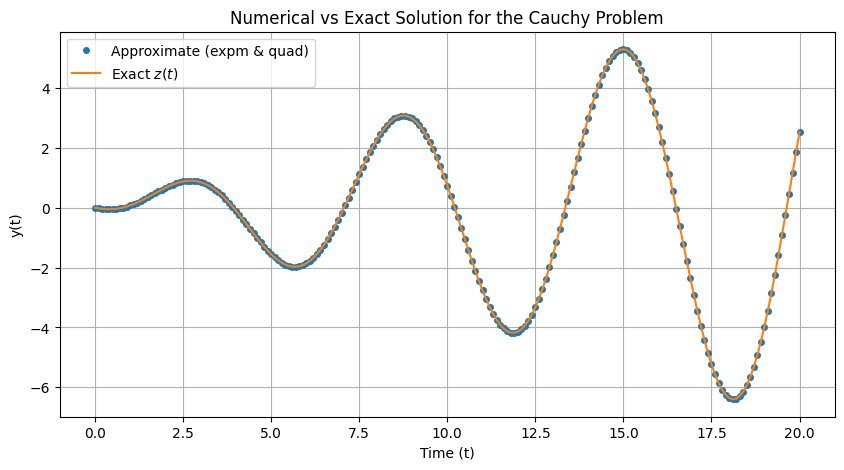

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm
from scipy.integrate import quad

# 1. Define matrices from Part (a)
A = np.array([[0, 1, 0],
              [0, 0, 1],
              [-1, -1, -1]])

def B_vec(t):
    return np.array([0, 0, np.cos(t)])

# 2. Initial conditions Y(0)
# Derived y''(0) = 0.5 based on the exact solution
Y0 = np.array([0, -0.25, 0.5]) 

# 3. Time domain
t_eval = np.arange(0, 20.1, 0.1)

# 4. Define the integrand for quad
# We extract the 0-th component because we only need y(t) (not y' or y'')
def integrand(s, t):
    return (expm((t - s) * A) @ B_vec(s))[0]

y_approx = []

# 5. Compute solution at each time step
for t in t_eval:
    # Homogeneous part: exp(tA) * Y0
    homo_part = (expm(t * A) @ Y0)[0]
    
    # Particular integral part
    part_int, _ = quad(integrand, 0, t, args=(t,))
    
    y_approx.append(homo_part + part_int)

# Exact solution for comparison
def z(t):
    return -0.25 * t * np.cos(t) + 0.25 * t * np.sin(t)

y_exact = z(t_eval)

# Plotting
plt.figure(figsize=(10, 5))
plt.plot(t_eval, y_approx, 'o', label='Approximate (expm & quad)', markersize=4)
plt.plot(t_eval, y_exact, '-', label='Exact $z(t)$')
plt.title('Numerical vs Exact Solution for the Cauchy Problem')
plt.xlabel('Time (t)')
plt.ylabel('y(t)')
plt.legend()
plt.grid(True)
plt.show()